# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectf** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 2** 

### **Réalisez votre feature engineering**

#### **Importation des Modules**

In [1]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


In [2]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


print("Importation des modules OK")

Importation des modules OK


#### **Chargement du jeu de données**

In [3]:
df = pd.read_csv("../data/processed/buildings_clean.csv")

print("Importation du dataset terminée.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Importation du dataset terminée.
Dimensions du dataset : 3348 lignes, 47 colonnes


#### **Exploration du jeu de données**

Avant de créer de nouvelles variables, il est important de vérifier la structure du jeu de données importé.

Cette première inspection permet de :
- vérifier les dimensions du dataset ;
- identifier les variables disponibles ;
- contrôler les types de données ;
- préparer les prochaines étapes du feature engineering.

In [4]:
# Aperçu général du dataset

display(df.head())

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

,osebuildingid,datayear,buildingtype,primarypropertytype,propertyname,address,city,state,zipcode,taxparcelidentificationnumber,...,electricity(kbtu),naturalgas(therms),naturalgas(kbtu),defaultdata,comments,compliancestatus,outlier,totalghgemissions,ghgemissionsintensity,usage_type
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83,Mono-usage
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86,Multi-usages
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19,Mono-usage
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67,Mono-usage
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88,Multi-usages


Nombre de lignes : 3348
Nombre de colonnes : 47


In [5]:
# Informations générales

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   osebuildingid                    3348 non-null   int64  
 1   datayear                         3348 non-null   int64  
 2   buildingtype                     3348 non-null   str    
 3   primarypropertytype              3348 non-null   str    
 4   propertyname                     3348 non-null   str    
 5   address                          3348 non-null   str    
 6   city                             3348 non-null   str    
 7   state                            3348 non-null   str    
 8   zipcode                          3332 non-null   float64
 9   taxparcelidentificationnumber    3348 non-null   str    
 10  councildistrictcode              3348 non-null   int64  
 11  neighborhood                     3348 non-null   str    
 12  latitude                       

#### **Identification des variables disponibles**
identifier les différentes features disponibles dans le jeu de données.

In [6]:
# Liste des colonnes

pd.set_option("display.max_rows", None)

display(pd.DataFrame({
    "Feature": df.columns,
    "Type": df.dtypes.values
}))

,Feature,Type
0,osebuildingid,int64
1,datayear,int64
2,buildingtype,str
3,primarypropertytype,str
4,propertyname,str
5,address,str
6,city,str
7,state,str
8,zipcode,float64
9,taxparcelidentificationnumber,str


> - Les variables directement liées à la consommation énergétique seront exclues afin d'éviter tout phénomène de **data leakage**.
> - Les nouvelles features seront principalement issues :
>  des caractéristiques structurelles du bâtiment ;
>  de son ancienneté ;
>  de son usage ;
>  de sa localisation.

### **Feature Engineering**

#### **Création de la variable BuildingAge**


> - Transformation de l'année de construction en âge du bâtiment.
> - Cette variable permet de mieux représenter l'ancienneté du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [7]:
# Création de l'âge du bâtiment

df["BuildingAge"] = df["datayear"] - df["yearbuilt"]

# Vérification
df[["yearbuilt", "datayear", "BuildingAge"]].head()

,yearbuilt,datayear,BuildingAge
0,1927,2016,89
1,1996,2016,20
2,1969,2016,47
3,1926,2016,90
4,1980,2016,36



> - Cette transformation permet d'améliorer l'interprétabilité de la variable et de représenter directement l'ancienneté des bâtiments.

#### **Création de la variable ParkingRatio**

> - Calcul de la proportion de la surface dédiée au parking.
> - Cette variable décrit la structure du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [8]:
# Création du ratio de surface de parking

df["ParkingRatio"] = (
    df["propertygfaparking"] / df["propertygfatotal"]
)

# Vérification
df[["propertygfaparking", "propertygfatotal", "ParkingRatio"]].head()

,propertygfaparking,propertygfatotal,ParkingRatio
0,0,88434,0.000000
1,15064,103566,0.145453
2,196718,956110,0.205748
3,0,61320,0.000000
4,62000,175580,0.353115


#### **Création de la variable BuildingRatio**

> - Calcul de la proportion de la surface occupée par le bâtiment.
> - Cette variable complète la description de la structure du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [9]:
# Création du ratio de surface du bâtiment

df["BuildingRatio"] = (
    df["propertygfabuilding(s)"] / df["propertygfatotal"]
)

# Vérification
df[["propertygfabuilding(s)", "propertygfatotal", "BuildingRatio"]].head()

,propertygfabuilding(s),propertygfatotal,BuildingRatio
0,88434,88434,1.000000
1,88502,103566,0.854547
2,759392,956110,0.794252
3,61320,61320,1.000000
4,113580,175580,0.646885


#### **Création de la variable IsMultiUse**

> - Identification des bâtiments ayant plusieurs types d'usages.
> - Cette variable décrit la diversité des usages du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [10]:
# Création d'une variable binaire indiquant plusieurs usages

df["IsMultiUse"] = (
    df["listofallpropertyusetypes"]
    .str.contains(",", na=False)
    .astype(int)
)

# Vérification
df[["listofallpropertyusetypes", "IsMultiUse"]].head()

,listofallpropertyusetypes,IsMultiUse
0,Hotel,0
1,"Hotel, Parking, Restaurant",1
2,Hotel,0
3,Hotel,0
4,"Hotel, Parking, Swimming Pool",1


#### **Création de la variable NumberPropertyUses**

> - Comptage du nombre de types d'usages du bâtiment.
> - Cette variable complète l'information apportée par **IsMultiUse**.
> - Elle est créée sans risque de **data leakage**.
> - Cette variable reflète la complexité fonctionnelle du bâtiment.

In [11]:
# Comptage du nombre de types d'usages

df["NumberPropertyUses"] = (
    df["listofallpropertyusetypes"]
    .str.split(",")
    .str.len()
)

# Vérification
df[["listofallpropertyusetypes", "NumberPropertyUses"]].head()

,listofallpropertyusetypes,NumberPropertyUses
0,Hotel,1
1,"Hotel, Parking, Restaurant",3
2,Hotel,1
3,Hotel,1
4,"Hotel, Parking, Swimming Pool",3


### **Suppression des variables peu pertinentes**

> Certaines variables sont supprimées car elles n'apportent pas d'information utile à la prédiction ou risquent d'introduire du **data leakage** :
> - les identifiants uniques ;
> - les informations administratives ou descriptives ;
> - les variables directement liées à la consommation énergétique.

In [12]:
# Variables candidates à supprimer

columns_to_drop = [

    # Identifiants
    "osebuildingid",
    "taxparcelidentificationnumber",

    # Informations descriptives
    "propertyname",
    "address",
    "comments",

    # Informations administratives
    "city",
    "state",
    "zipcode",

    # Variables énergétiques (data leakage)
    "siteeui(kbtu/sf)",
    "siteeuiwn(kbtu/sf)",
    "sourceeui(kbtu/sf)",
    "sourceeuiwn(kbtu/sf)",
    "siteenergyusewn(kbtu)",
    "steamuse(kbtu)",
    "electricity(kwh)",
    "electricity(kbtu)",
    "naturalgas(therms)",
    "naturalgas(kbtu)",
    "totalghgemissions",
]

columns_to_drop

['osebuildingid',
 'taxparcelidentificationnumber',
 'propertyname',
 'address',
 'comments',
 'city',
 'state',
 'zipcode',
 'siteeui(kbtu/sf)',
 'siteeuiwn(kbtu/sf)',
 'sourceeui(kbtu/sf)',
 'sourceeuiwn(kbtu/sf)',
 'siteenergyusewn(kbtu)',
 'steamuse(kbtu)',
 'electricity(kwh)',
 'electricity(kbtu)',
 'naturalgas(therms)',
 'naturalgas(kbtu)',
 'totalghgemissions']

In [13]:
# Suppression des variables peu pertinentes

df = df.drop(columns=columns_to_drop)

print(f"Nombre de colonnes restantes : {df.shape[1]}")

display(df.head())

Nombre de colonnes restantes : 33


,datayear,buildingtype,primarypropertytype,councildistrictcode,neighborhood,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,...,defaultdata,compliancestatus,outlier,ghgemissionsintensity,usage_type,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,...,False,Compliant,NaN,2.83,Mono-usage,89,0.000000,1.000000,0,1
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,...,False,Compliant,NaN,2.86,Multi-usages,20,0.145453,0.854547,1,3
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,False,Compliant,NaN,2.19,Mono-usage,47,0.205748,0.794252,0,1
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,...,False,Compliant,NaN,4.67,Mono-usage,90,0.000000,1.000000,0,1
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,False,Compliant,NaN,2.88,Multi-usages,36,0.353115,0.646885,1,3


> - Les variables identifiées précédemment sont supprimées afin de conserver uniquement les informations pertinentes pour la modélisation.

### **Analyse des variables après Feature Engineering**

> -  la distribution de la variable cible est analysée afin d'identifier une éventuelle asymétrie ou la présence de valeurs extrêmes.
> - Cette étape permet également de déterminer si une transformation (par exemple logarithmique) sera nécessaire avant la modélisation.

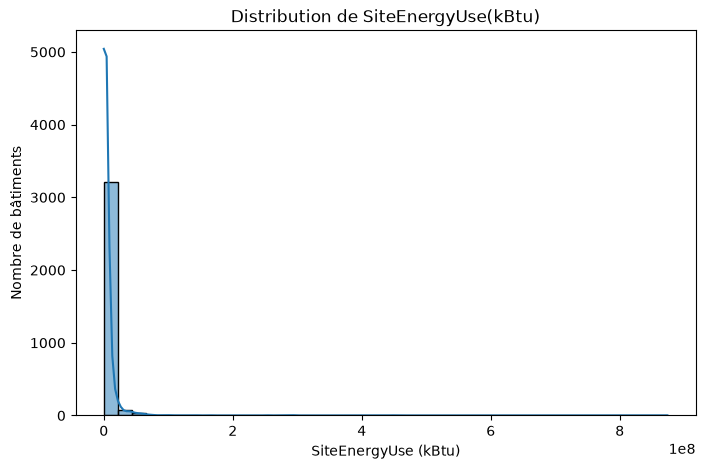

In [14]:
# Distribution de la variable cible

plt.figure(figsize=(8,5))

sns.histplot(
    df["siteenergyuse(kbtu)"],
    bins=40,
    kde=True
)

plt.title("Distribution de SiteEnergyUse(kBtu)")
plt.xlabel("SiteEnergyUse (kBtu)")
plt.ylabel("Nombre de bâtiments")

plt.show()

#### **Analyse des valeurs extrêmes**

> -  Un boxplot est utilisé afin de visualiser la présence d'éventuelles valeurs extrêmes de la variable cible.
> -  Les observations identifiées seront analysées avant toute décision de suppression, car elles peuvent correspondre à de grands bâtiments et non à des erreurs de mesure.

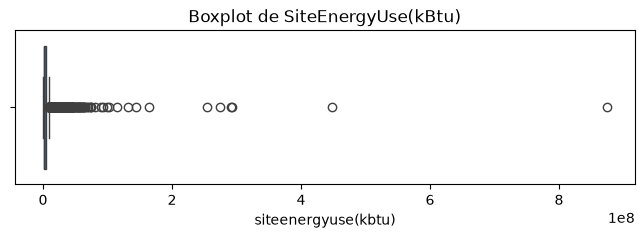

In [15]:
# Visualisation des valeurs extrêmes

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["siteenergyuse(kbtu)"]
)

plt.title("Boxplot de SiteEnergyUse(kBtu)")

plt.show()

> -  Une matrice de corrélation de Pearson est utilisée afin d'identifier les variables numériques fortement corrélées.
> - Cette analyse permet de détecter les variables redondantes susceptibles d'apporter une information similaire au modèle

#### **Analyse de la corrélation**

> -  Les valeurs extrêmes correspondent majoritairement à des bâtiments de grande taille et font partie de la variabilité naturelle du jeu de données. Elles sont donc conservées pour la modélisation.

In [16]:
# Sélection des variables numériques

numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,datayear,councildistrictcode,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,propertygfatotal,propertygfaparking,propertygfabuilding(s),...,secondlargestpropertyusetypegfa,thirdlargestpropertyusetypegfa,energystarscore,siteenergyuse(kbtu),ghgemissionsintensity,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
0,2016,7,47.61220,-122.33799,1927,1.0,12,88434,0,88434,...,NaN,NaN,60.0,7226362.5,2.83,89,0.000000,1.000000,0,1
1,2016,7,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,...,15064.0,4622.0,61.0,8387933.0,2.86,20,0.145453,0.854547,1,3
2,2016,7,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,...,NaN,NaN,43.0,72587024.0,2.19,47,0.205748,0.794252,0,1
3,2016,7,47.61412,-122.33664,1926,1.0,10,61320,0,61320,...,NaN,NaN,56.0,6794584.0,4.67,90,0.000000,1.000000,0,1
4,2016,7,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,...,68009.0,0.0,75.0,14172606.0,2.88,36,0.353115,0.646885,1,3


In [17]:
# Matrice de corrélation

corr_matrix = numeric_df.corr(method="pearson")

corr_matrix.head()

,datayear,councildistrictcode,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,propertygfatotal,propertygfaparking,propertygfabuilding(s),...,secondlargestpropertyusetypegfa,thirdlargestpropertyusetypegfa,energystarscore,siteenergyuse(kbtu),ghgemissionsintensity,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
datayear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
councildistrictcode,NaN,1.000000,0.488993,-0.266815,-0.018669,-0.013213,0.250594,0.096711,0.133687,0.080936,...,0.140600,0.017799,0.059775,0.040298,0.002805,0.018669,0.125168,-0.125168,0.106887,0.117477
latitude,NaN,0.488993,1.000000,0.003416,0.117768,0.020817,-0.022826,-0.017450,-0.000782,-0.018253,...,-0.053304,-0.107349,0.079203,-0.021128,-0.040537,-0.117768,0.032087,-0.032087,-0.005519,-0.023181
longitude,NaN,-0.266815,0.003416,1.000000,-0.052976,0.017926,-0.026788,0.025564,-0.003521,0.027472,...,0.018166,0.027265,-0.027284,0.033764,0.040706,0.052976,-0.024314,0.024314,-0.027592,-0.013313
yearbuilt,NaN,-0.018669,0.117768,-0.052976,1.000000,-0.023681,0.146615,0.100352,0.183814,0.076932,...,0.202779,0.091195,0.028443,0.027710,-0.145641,-1.000000,0.224810,-0.224810,0.125958,0.095785


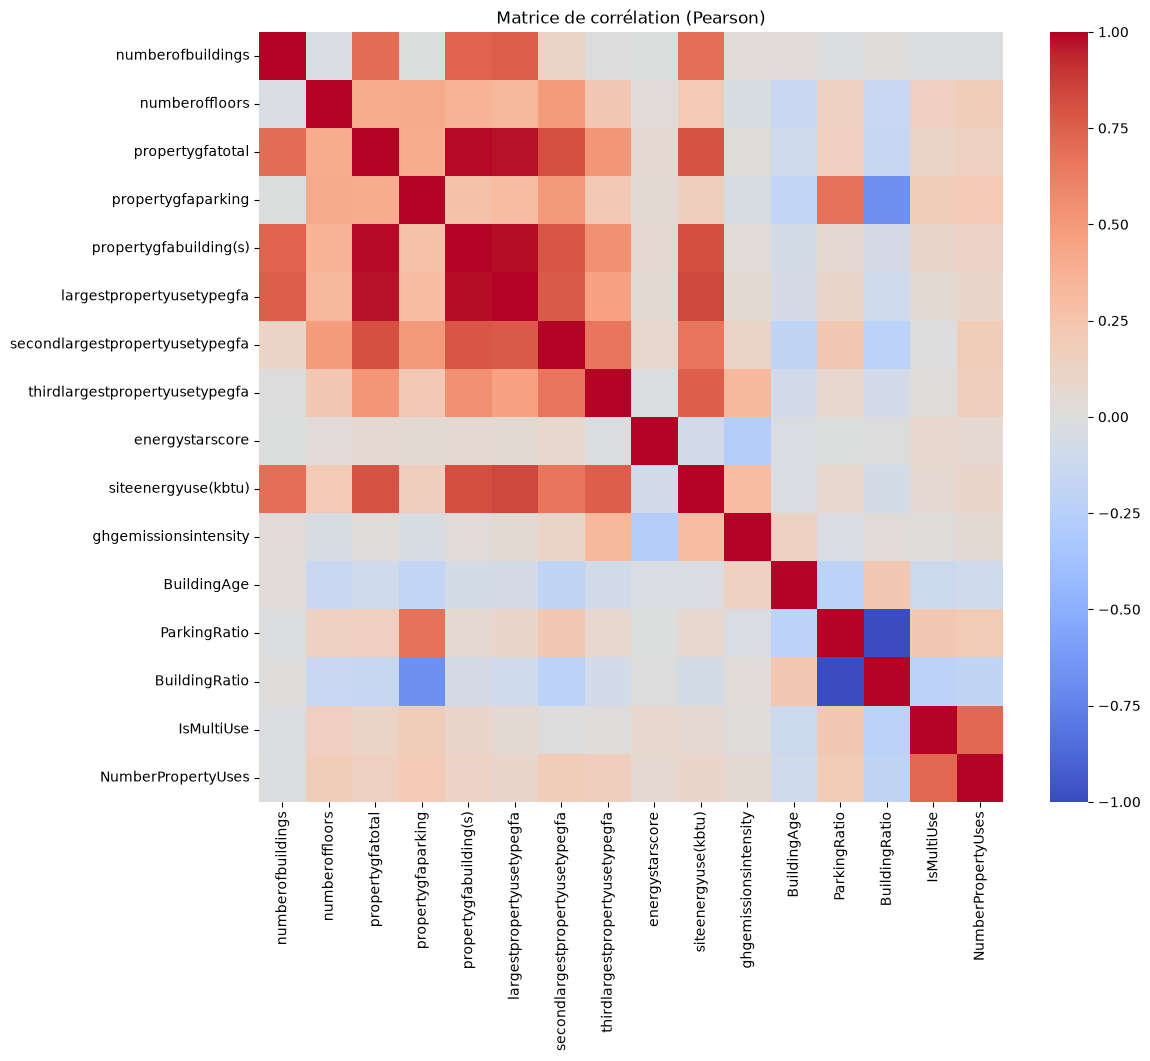

siteenergyuse(kbtu)                1.000000
largestpropertyusetypegfa          0.839765
propertygfabuilding(s)             0.817286
propertygfatotal                   0.801526
thirdlargestpropertyusetypegfa     0.754093
numberofbuildings                  0.690769
secondlargestpropertyusetypegfa    0.662201
ghgemissionsintensity              0.310448
numberoffloors                     0.205420
propertygfaparking                 0.171216
NumberPropertyUses                 0.099924
ParkingRatio                       0.073327
IsMultiUse                         0.062917
BuildingAge                       -0.027710
BuildingRatio                     -0.073327
energystarscore                   -0.089974
Name: siteenergyuse(kbtu), dtype: float64

In [18]:
# Variables retenues pour l'analyse de corrélation

corr_df = df[
    [
        "numberofbuildings",
        "numberoffloors",
        "propertygfatotal",
        "propertygfaparking",
        "propertygfabuilding(s)",
        "largestpropertyusetypegfa",
        "secondlargestpropertyusetypegfa",
        "thirdlargestpropertyusetypegfa",
        "energystarscore",
        "siteenergyuse(kbtu)",
        "ghgemissionsintensity",
        "BuildingAge",
        "ParkingRatio",
        "BuildingRatio",
        "IsMultiUse",
        "NumberPropertyUses"
    ]
]

# Matrice de corrélation
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation (Pearson)")
plt.show()

# Corrélations avec la variable cible

corr_target = (
    corr_matrix["siteenergyuse(kbtu)"]
    .sort_values(ascending=False)
)

display(corr_target)

> - Le boxplot met en évidence la présence de valeurs extrêmes pour **SiteEnergyUse(kBtu)**, qui sont conservées car elles correspondent principalement à de grands bâtiments.
> - La matrice de corrélation montre que les variables de surface (**LargestPropertyUseTypeGFA**, **PropertyGFABuilding(s)** et **PropertyGFATotal**) présentent les corrélations les plus élevées avec **SiteEnergyUse(kBtu)**.
> - Les variables créées (**BuildingAge**, **ParkingRatio**, **BuildingRatio**, **IsMultiUse** et **NumberPropertyUses**) apportent une information complémentaire, avec des corrélations plus faibles mais potentiellement utiles pour la modélisation.
> - Les nouvelles variables seront évaluées lors de la modélisation

#### **Analyse des relations entre les features et la variable cible**

##### **LargestPropertyUseTypeGFA**

> - Un nuage de points est utilisé afin de visualiser la relation entre la surface principale du bâtiment (**LargestPropertyUseTypeGFA**) et la consommation énergétique (**SiteEnergyUse(kBtu)**).

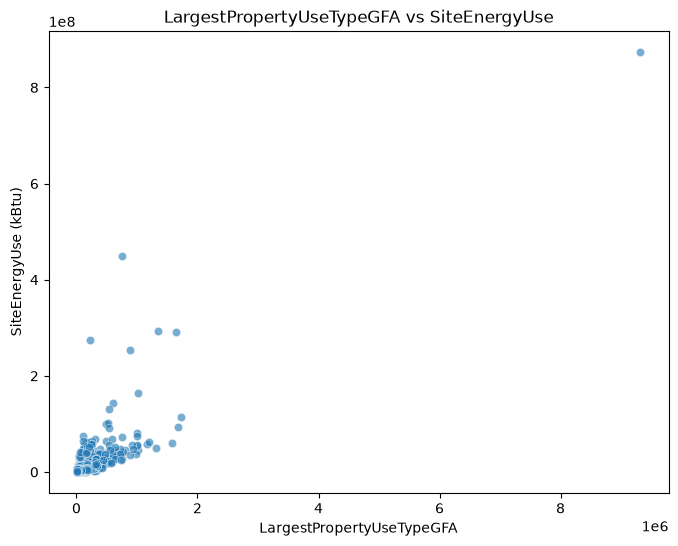

In [19]:
# Relation entre LargestPropertyUseTypeGFA et SiteEnergyUse

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="largestpropertyusetypegfa",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

plt.title("LargestPropertyUseTypeGFA vs SiteEnergyUse")
plt.xlabel("LargestPropertyUseTypeGFA")
plt.ylabel("SiteEnergyUse (kBtu)")

plt.show()

> - Le nuage de points montre une corrélation positive entre **LargestPropertyUseTypeGFA** et **SiteEnergyUse(kBtu)**.
> - Les bâtiments ayant une plus grande surface principale présentent généralement une consommation énergétique plus élevée. Quelques valeurs extrêmes sont observées, mais elles correspondent à de grands bâtiments déjà identifiés précédemment.

##### **PropertyGFATotal**

> - Un second nuage de points est réalisé afin d'observer la relation entre la surface totale du bâtiment (**PropertyGFATotal**) et la consommation énergétique.

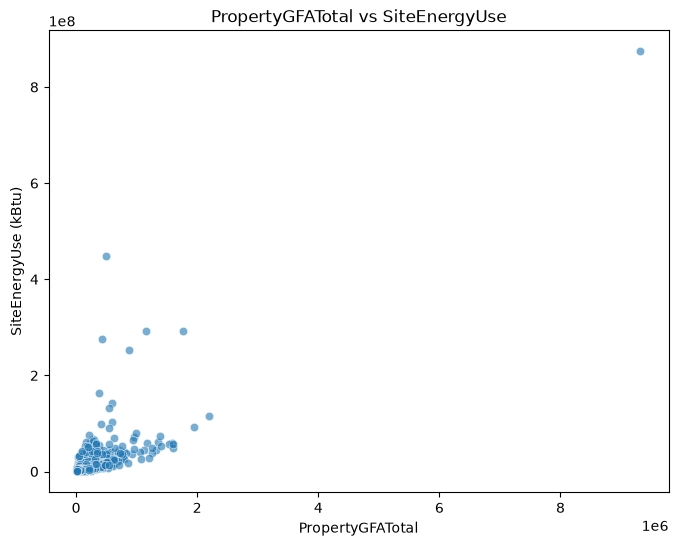

In [20]:
# Relation entre PropertyGFATotal et SiteEnergyUse

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="propertygfatotal",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

plt.title("PropertyGFATotal vs SiteEnergyUse")
plt.xlabel("PropertyGFATotal")
plt.ylabel("SiteEnergyUse (kBtu)")

plt.show()

> - Le nuage de points montre une corrélation positive entre **PropertyGFATotal** et **SiteEnergyUse(kBtu)**.
> - Les bâtiments ayant une plus grande surface totale présentent généralement une consommation énergétique plus élevée. Cette relation est cohérente avec les résultats obtenus lors de l'analyse de corrélation.

### **Suppression des variables administratives**

In [21]:
# Suppression des variables administratives

columns_to_remove = [
    "compliancestatus",
    "outlier",
    "yearsenergystarcertified"
]

df = df.drop(columns=columns_to_remove)

print(f"Dimensions du jeu de données : {df.shape}")

# Vérification des variables catégorielles restantes
categorical_features = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(f"Nombre de variables catégorielles : {len(categorical_features)}")
print(categorical_features)

display(df.head())

Dimensions du jeu de données : (3348, 30)
Nombre de variables catégorielles : 8
['buildingtype', 'primarypropertytype', 'neighborhood', 'listofallpropertyusetypes', 'largestpropertyusetype', 'secondlargestpropertyusetype', 'thirdlargestpropertyusetype', 'usage_type']


,datayear,buildingtype,primarypropertytype,councildistrictcode,neighborhood,latitude,longitude,yearbuilt,numberofbuildings,numberoffloors,...,energystarscore,siteenergyuse(kbtu),defaultdata,ghgemissionsintensity,usage_type,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,...,60.0,7226362.5,False,2.83,Mono-usage,89,0.000000,1.000000,0,1
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,...,61.0,8387933.0,False,2.86,Multi-usages,20,0.145453,0.854547,1,3
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,...,43.0,72587024.0,False,2.19,Mono-usage,47,0.205748,0.794252,0,1
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,...,56.0,6794584.0,False,4.67,Mono-usage,90,0.000000,1.000000,0,1
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,...,75.0,14172606.0,False,2.88,Multi-usages,36,0.353115,0.646885,1,3


> - Le jeu de données contient désormais 30 variables après la suppression des variables non pertinentes.
> - Les données sont prêtes pour la séparation entre les variables explicatives et la variable cible.

## **Conclusion**

> - Cinq nouvelles variables ont été créées afin d'enrichir le jeu de données.
> - Les variables peu pertinentes ainsi que celles susceptibles d'introduire du data leakage ont été supprimées.
> - Les variables administratives ont été retirées afin de conserver uniquement les informations utiles à la modélisation.

> Le jeu de données est désormais prêt pour les étapes de préparation des données et de modélisation.

## **Sauvegarde du jeu de données**

In [23]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

df.to_csv(
    "../data/processed/buildings_features.csv",
    index=False
)

print("Jeu de données sauvegardé avec succès : buildings_features.csv")

Jeu de données sauvegardé avec succès : buildings_features.csv
